# Data Preparation — Churn Prediction

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [2]:
customer_data = pd.read_csv("data/lake/customer_data.csv")

In [3]:
customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']] = (
    customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']]
        .apply(pd.to_datetime, errors='coerce', dayfirst=True, format='%d/%m/%Y')
    )

In [4]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(customer_data, test_size=0.2, random_state=42)

In [5]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 46439 entries, 32588 to 56422
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CODE                          46439 non-null  str           
 1   Sales_Date                    46439 non-null  datetime64[us]
 2   Id_Producto                   46439 non-null  str           
 3   Customer_ID                   46439 non-null  int64         
 4   PVP                           46439 non-null  int64         
 5   MOTIVO_VENTA                  46439 non-null  str           
 6   FORMA_PAGO                    46439 non-null  str           
 7   EXTENSION_GARANTIA            46439 non-null  str           
 8   SEGURO_BATERIA_LARGO_PLAZO    46439 non-null  str           
 9   MANTENIMIENTO_GRATUITO        46439 non-null  int64         
 10  FIN_GARANTIA                  46439 non-null  datetime64[us]
 11  BASE_DATE                     46439 non-

In [6]:
test_set.to_csv("data/warehouse/test_set.csv", index=False)

## Transformar todas las variables dicotómicas a numéricas, utilizando One-Hot Encoding para las variables categóricas

In [7]:
class BinaryEncoder(BaseEstimator, TransformerMixin):


    binary_sinno_columns = [
        'SEGURO_BATERIA_LARGO_PLAZO', 'EN_GARANTIA',
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        for col in self.binary_sinno_columns:
            X[col] = X[col].map({'SI': 1, 'NO': 0})


        X['MANTENIMIENTO_GRATUITO'] *= 0.25
        X['QUEJA'] = X['QUEJA'].fillna('NO').map({'SI': 1, 'NO': 0})
        X['Churn_400'] = X['Churn_400'].map({'Y': 1, 'N': 0})

        return X

class FrequencyEncoder(BaseEstimator, TransformerMixin):

    high_cardinality_columns = ['Modelo', 'PROV_DESC']

    def __init__(self):
        self.frequency_maps_ = {}

    def fit(self, X, y=None):
        for col in self.high_cardinality_columns:
            self.frequency_maps_[col] = X[col].value_counts(normalize=True)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in self.high_cardinality_columns:
            X[col] = X[col].map(self.frequency_maps_[col]).fillna(0)
        return X

class OrdinalExtensionEncoder(BaseEstimator, TransformerMixin):
    """
    OrdinalEncoder con orden explícito para EXTENSION_GARANTIA.
    'SI, Campa a regalo' se trata como 'SI, Financiera'.
    """
    REMAP = {'SI, Campa a Regalo': 'SI, Financiera'}
    ORDER = ['NO', 'SI', 'SI, Financiera']

    def __init__(self):
        # 1. Le indicamos el orden explícito que queremos que respete
        self.encoder = OrdinalEncoder(categories=[self.ORDER])

    def fit(self, X, y=None):
        Xt = X[['EXTENSION_GARANTIA']].copy()
        # Remapeamos antes de ajustar
        Xt['EXTENSION_GARANTIA'] = Xt['EXTENSION_GARANTIA'].replace(self.REMAP)
        self.encoder.fit(Xt)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # 2. PRIMERO REMAPEAMOS en los datos nuevos (fundamental para que el encoder lo entienda)
        X['EXTENSION_GARANTIA'] = X['EXTENSION_GARANTIA'].replace(self.REMAP)

        # 3. LUEGO HACEMOS EL ENCODING
        X['EXTENSION_GARANTIA'] = self.encoder.transform(X[['EXTENSION_GARANTIA']])

        return X

class OrdinalEquipamientoEncoder(BaseEstimator, TransformerMixin):

    ORDER = ['Low', 'Mid', 'Mid-High', 'High']

    def __init__(self):
        self.encoder = OrdinalEncoder(
            categories=[self.ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )

    def fit(self, X, y=None):
        self.encoder.fit(X[['Equipamiento']].astype(str))
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['Equipamiento'] = self.encoder.transform(X[['Equipamiento']].astype(str))
        return X

class NominalOneHotEncoder(BaseEstimator, TransformerMixin):
    """
    OneHotEncoder para todas las variables nominales sin orden implícito,
    incluyendo las de media/alta cardinalidad no cubiertas por FrequencyEncoder.
    """

    nominal_columns = [
        # categorical_labeled_variables nominales
        'MOTIVO_VENTA', 'GENERO', 'Fuel', 'TRANSMISION_ID', 'Origen',
        # categorical_multilabeled_variables nominales
        'FORMA_PAGO', 'STATUS_SOCIAL', 'TIPO_CARROCERIA', 'ZONA',
    ]

    def __init__(self):
        self.encoder = OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
        self.feature_names_ = None

    def fit(self, X, y=None):
        self.encoder.fit(X[self.nominal_columns])
        self.feature_names_ = self.encoder.get_feature_names_out(self.nominal_columns)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        encoded = self.encoder.transform(X[self.nominal_columns])
        encoded_df = pd.DataFrame(encoded, columns=self.feature_names_, index=X.index)
        X.drop(columns=self.nominal_columns, inplace=True)
        return pd.concat([X, encoded_df], axis=1)


class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Elimina columnas sin poder predictivo.
    Cambia unuseful_columns para experimentar con distintas combinaciones.
    """

    unuseful_columns = [
        # Identificadores
        'CODE', 'Id_Producto', 'Customer_ID',
        # Fechas brutas
        'Sales_Date', 'FIN_GARANTIA', 'BASE_DATE',
        # Leakage económico
        'Margen_eur_bruto', 'Margen_eur', 'COSTE_VENTA_NO_IMPUESTOS',
        # Geografía redundante
        'CODIGO_POSTAL', 'ZONA',
        # Taller redundante
        'Revisiones', 'TIENDA_DESC', 'Km_medio_por_revision', 'km_ultima_revision',
        # Sensibles
        'STATUS_SOCIAL', 'GENERO',
        # Resto
        'ENCUESTA_CLIENTE_ZONA_TALLER', 'DAYS_LAST_SERVICE', 'RENTA_MEDIA_ESTIMADA'
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # Las columnas OneHot generadas llevan prefijo (ej: GENERO_H, ZONA_Norte)
        # por eso buscamos también por prefijo
        cols_to_drop = [
            c for c in X.columns
            if c in self.unuseful_columns
               or any(c.startswith(f'{base}_') for base in self.unuseful_columns)
        ]
        X.drop(columns=cols_to_drop, inplace=True, errors='ignore')
        return X

In [8]:
full_pipeline = Pipeline([
    ('binary',          BinaryEncoder()),
    ('frequency',       FrequencyEncoder()),
    ('ordinal_ext',     OrdinalExtensionEncoder()),
    ('ordinal_equip',   OrdinalEquipamientoEncoder()),
    ('onehot',          NominalOneHotEncoder()),
    ('dropper',         ColumnDropper()),
])

In [9]:
train_set_prepared = full_pipeline.fit_transform(train_set)
print("Shape final:", train_set_prepared.shape)

Shape final: (46439, 34)


In [10]:
train_set_prepared.info()

<class 'pandas.DataFrame'>
Index: 46439 entries, 32588 to 56422
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PVP                           46439 non-null  int64  
 1   EXTENSION_GARANTIA            46439 non-null  float64
 2   SEGURO_BATERIA_LARGO_PLAZO    46439 non-null  int64  
 3   MANTENIMIENTO_GRATUITO        46439 non-null  float64
 4   EN_GARANTIA                   46439 non-null  int64  
 5   Edad                          46439 non-null  int64  
 6   Modelo                        46439 non-null  float64
 7   Equipamiento                  46439 non-null  float64
 8   Kw                            46439 non-null  int64  
 9   QUEJA                         46439 non-null  int64  
 10  Lead_compra                   46439 non-null  int64  
 11  Fue_Lead                      46439 non-null  int64  
 12  PROV_DESC                     46439 non-null  float64
 13  Churn_400    

array([[<Axes: title={'center': 'PVP'}>,
        <Axes: title={'center': 'EXTENSION_GARANTIA'}>,
        <Axes: title={'center': 'SEGURO_BATERIA_LARGO_PLAZO'}>,
        <Axes: title={'center': 'MANTENIMIENTO_GRATUITO'}>,
        <Axes: title={'center': 'EN_GARANTIA'}>,
        <Axes: title={'center': 'Edad'}>],
       [<Axes: title={'center': 'Modelo'}>,
        <Axes: title={'center': 'Equipamiento'}>,
        <Axes: title={'center': 'Kw'}>,
        <Axes: title={'center': 'QUEJA'}>,
        <Axes: title={'center': 'Lead_compra'}>,
        <Axes: title={'center': 'Fue_Lead'}>],
       [<Axes: title={'center': 'PROV_DESC'}>,
        <Axes: title={'center': 'Churn_400'}>,
        <Axes: title={'center': 'MOTIVO_VENTA_No Particular'}>,
        <Axes: title={'center': 'MOTIVO_VENTA_Particular'}>,
        <Axes: title={'center': 'Fuel_ELÉCTRICO'}>,
        <Axes: title={'center': 'Fuel_HÍBRIDO'}>],
       [<Axes: title={'center': 'TRANSMISION_ID_A'}>,
        <Axes: title={'center': 'TRANS

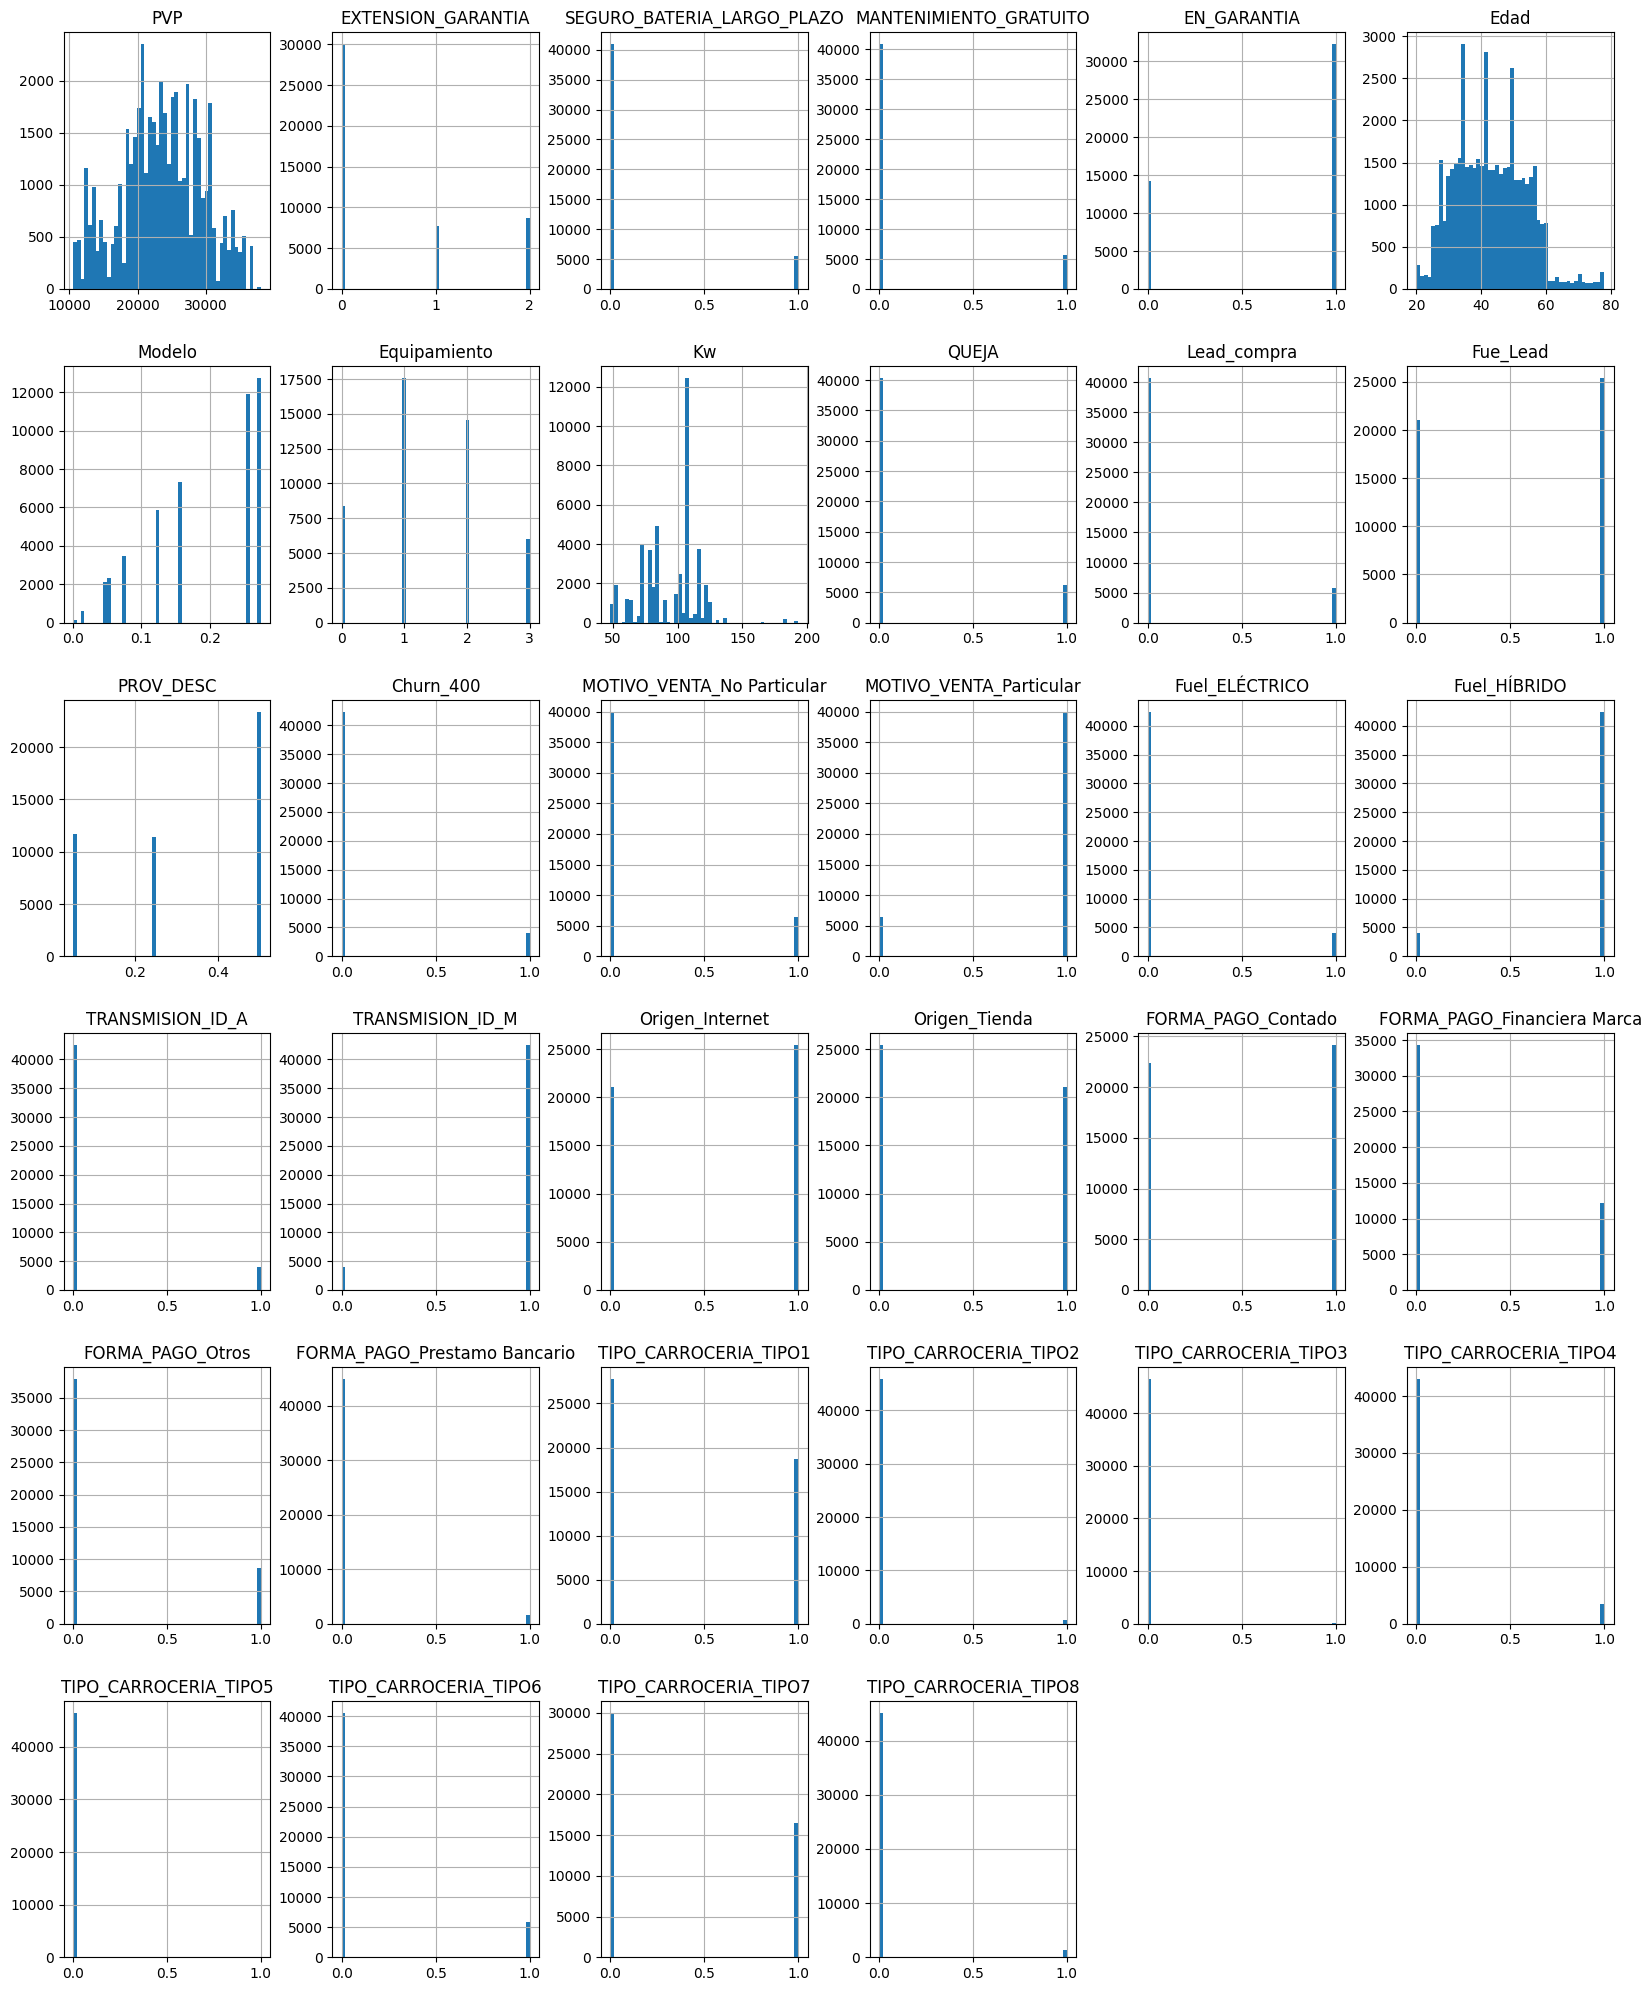

In [11]:
train_set_prepared.hist(bins=50, figsize=(20, 25))